## CNN-based remote sensing multispectral image sceneclassification

## 1. Importing libraries

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # Suppress TensorFlow logs
import tensorflow as tf

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Restrict TensorFlow to only use the first GPU (index 0)
        tf.config.set_visible_devices(gpus[0], 'GPU')
        # Optionally, enable memory growth if needed
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Using GPU:", gpus[0])
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# !pip install visualkeras >> /dev/null
# !pip install seaborn >> /dev/null

In [ ]:
import os, pathlib, pprint
import numpy as np
import pandas as pd

import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import visualkeras
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, cohen_kappa_score, mean_squared_error, r2_score

from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Activation, Add, Dense, Input, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback

## 2. Image preprocessing

{'count': 13,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32633"]]'),
 'driver': 'GTiff',
 'dtype': 'uint16',
 'height': 64,
 'nodata': None,
 'transform': Affine(10.00512436075951, 0.0, 493616.0809594494,
       0.0, -9.993460927833883, 6594953.910789382),
 'width': 64}


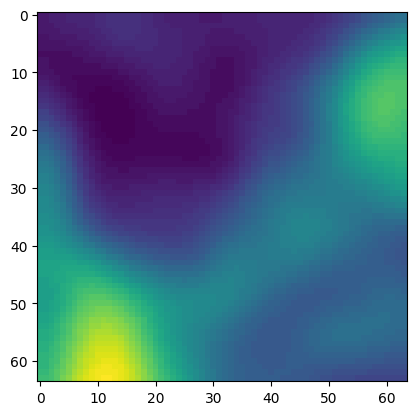

In [ ]:
with rasterio.open('./data/Forest/Forest_15.tif') as src:
    meta = src.meta
    pprint.pprint(meta)

    plt.imshow(src.read()[0, :, :])
    plt.show()

In [ ]:
def dataLoader(data_dir, imgRows=64, imgCols=64, bands=13, testSize=0.30, randomState=24):
    """
    Load image data from subdirectories in 'data_dir', assigns labels based on folder names,
    and splits the data into training and testing sets.
    """

    # Initialize lists to hold image data and labels
    X_data, y_data = [], []
    label = 0  # Label counter for each class
    dataPath = pathlib.Path(data_dir)  # Create a pathlib.Path object for the data directory

    # Iterate over each subdirectory (each representing a class)
    for eachPath in sorted(dataPath.iterdir()):
        if eachPath.is_dir():
            # Get all TIFF files in the current class folder
            imgListPerClass = list(eachPath.glob('*.tif'))
            X_class = []  # List to store images for this class

            # Process each image in the current class folder
            for imgPath in imgListPerClass:
                # Open the image, read its data, and transpose from (bands, rows, columns)
                # to (rows, columns, bands)
                rasterArr = rasterio.open(imgPath).read().transpose(1, 2, 0)
                X_class.append(rasterArr)

            # Convert the list of images to a numpy array
            X_class = np.array(X_class)
            # Create an array of labels for this class, one label per image
            y_class = np.full((X_class.shape[0],), label)

            # Append the class-specific image data and labels to the global lists
            X_data.append(X_class)
            y_data.append(y_class)

            # Increment the label for the next class
            label += 1

    # Concatenate all class arrays into single arrays
    X_data = np.concatenate(X_data, axis=0)
    y_data = np.concatenate(y_data, axis=0)

    # Split the data into training and testing sets
    # 'stratify=y_data' ensures that the class distribution is preserved in both splits.
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=testSize, random_state=randomState, stratify=y_data
    )

    return X_train, X_test, y_train, y_test

# Load data from the specified directory
X_train, X_test, y_train, y_test = dataLoader(r'./data')

# One-hot encode the labels:

# Determine the number of unique classes from the training labels
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# Convert integer labels to one-hot encoded vectors
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

Number of classes: 5


In [ ]:
# validating training/test split is balanced for each class after stratification

# Convert labels to a pandas Series
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

print("Training set class distribution:")
print(train_counts)

print("\nTest set class distribution:")
print(test_counts)

Training set class distribution:
0    140
1    140
2    140
3    140
4    140
Name: count, dtype: int64

Test set class distribution:
0    60
1    60
2    60
3    60
4    60
Name: count, dtype: int64


In [ ]:
# Print the shapes of the datasets for verification
print("X_train shape:", X_train.shape)
print("y_train (one-hot) shape:", y_train_encoded.shape)
print("X_test shape:", X_test.shape)
print("y_test (one-hot) shape:", y_test_encoded.shape)

X_train shape: (700, 64, 64, 13)
y_train (one-hot) shape: (700, 5)
X_test shape: (300, 64, 64, 13)
y_test (one-hot) shape: (300, 5)


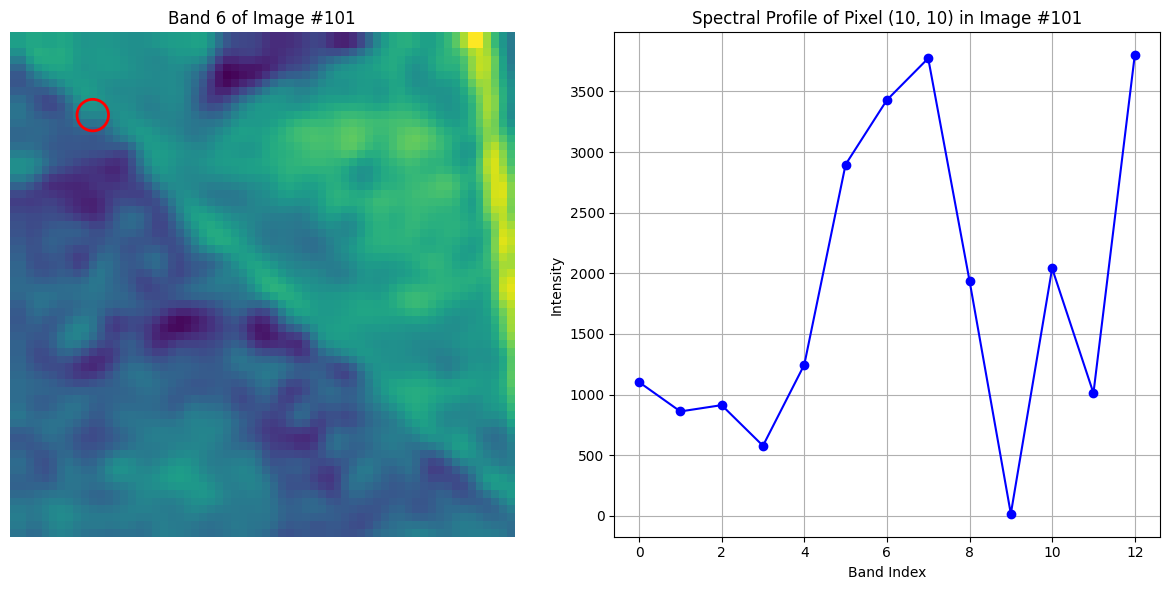

In [ ]:
# Create a figure with two subplots (side by side) that share the same height
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Left subplot: Display the 5th band of image #101 and add a red circle around (10, 10)
ax1.imshow(X_train[100][:, :, 4])
ax1.set_title("Band 6 of Image #101")
ax1.axis('off')  # Hide axis for a cleaner image display

# Create and add a red circle to highlight the pixel at (10, 10)
circle = patches.Circle((10, 10), radius=2, edgecolor='red', facecolor='none', linewidth=2)
ax1.add_patch(circle)

# Right subplot: Plot the spectral profile (all bands) of the pixel at (10, 10)
pixel_profile = X_train[100][10, 10, :]  # Extract spectral data for the pixel
ax2.plot(pixel_profile, marker='o', linestyle='-', color='b')
ax2.set_title("Spectral Profile of Pixel (10, 10) in Image #101")
ax2.set_xlabel("Band Index")
ax2.set_ylabel("Intensity")
ax2.grid(True)

# Adjust layout to avoid overlapping and match heights
plt.tight_layout()
plt.show()

## 3. Applying a custom-designed CNN model for remote sensing image classification

### 3.1 Custom design a CNN architecture

In [ ]:
def customCNN(input_shape, numClasses):
    inputs = Input(shape = input_shape, name = "Input")

    # First Convolution Block
    x = Conv2D(32, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same', name='conv1')(inputs)
    x = MaxPooling2D(pool_size=(2, 2), name='pool1')(x)

    # Second Convolution Block
    x = Conv2D(32, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same', name='conv2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
    # x = BatchNormalization(name='bn1')(x)

    # Third Convolution Block
    x = Conv2D(64, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same', name='conv3')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool3')(x)

    # Dropout 1
    x = Dropout(0.2, name='dropout1')(x)

    # Flatten the output and add fully connected layers
    x = Flatten(name='flatten')(x)
    x = Dense(64, activation='relu', name='fc_64')(x)
    x = Dense(128, activation='relu', name='fc_128')(x)
    x = Dense(256, activation='relu', name='fc_256')(x)

    # Output layer with softmax activation for classification
    outputs = Dense(numClasses, activation='softmax', name='output')(x)

    # Create the model
    model = Model(inputs=inputs, outputs=outputs, name='custom_cnn')

    return model

### 3.2 Custom designed CNN model training and testing

#### 3.2.1 CNN model compile and training

In [ ]:
# You may use either sequantial API or functional API
inputShape = X_train[0].shape
print(inputShape)

(64, 64, 13)


In [ ]:
num_classes = y_train_encoded.shape[1]
print(num_classes)

5


In [ ]:
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(X_train, y_train_encoded, test_size=0.25, random_state=42)

# Build training dataset
batch_size = 16

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded)) \
                                 .shuffle(1024, reshuffle_each_iteration=True) \
                                 .batch(batch_size, drop_remainder=True) \
                                 .prefetch(tf.data.AUTOTUNE)

# Build validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded)) \
                                .batch(batch_size, drop_remainder=True) \
                                .prefetch(tf.data.AUTOTUNE)

model = customCNN(input_shape=inputShape, numClasses = num_classes)
model.compile(optimizer=Adam(learning_rate=1e-5),  loss='categorical_crossentropy', metrics=['accuracy'])

I0000 00:00:1743625809.280766 2324322 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:17:00.0, compute capability: 8.0


In [ ]:
model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_64 (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_128 (Dense)                  │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_256 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,357 (1.28 MB)

 Trainable params: 336,357 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

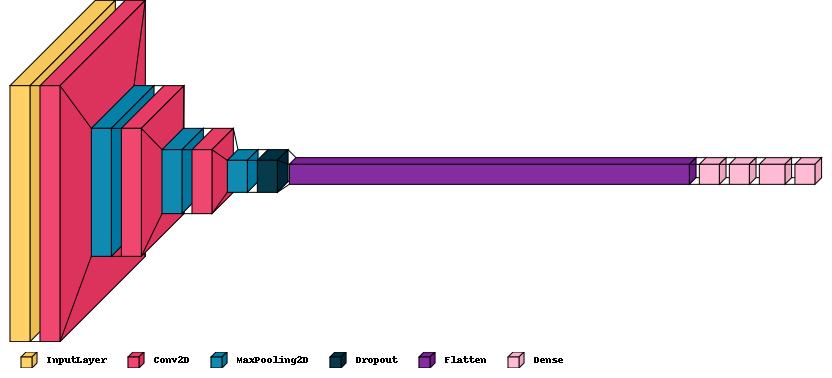

In [ ]:
visualkeras.layered_view(model, legend=True)

#### 3.2.2 CNN model training history visulization

In [ ]:
checkpoint_path = './best_model_CNN.keras'

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

class VerboseEvery10(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: "
                  f"Loss={logs['loss']:.4f}, Validation Loss={logs['val_loss']:.4f}, "
                  f"Accuracy={logs['accuracy']:.4f}, Validation Accuracy={logs['val_accuracy']:.4f}")

In [ ]:
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=400,
    callbacks=[checkpoint, VerboseEvery10()],
    verbose=0
)

I0000 00:00:1743625826.558080 2344318 service.cc:152] XLA service 0x155258010fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743625826.558129 2344318 service.cc:160]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1743625827.137401 2344318 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1743625834.393294 2344318 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 10: Loss=32.2372, Validation Loss=16.4824, Accuracy=0.4961, Validation Accuracy=0.6500
Epoch 20: Loss=15.7119, Validation Loss=7.2044, Accuracy=0.5918, Validation Accuracy=0.6938
Epoch 30: Loss=10.0368, Validation Loss=3.6301, Accuracy=0.6426, Validation Accuracy=0.7812
Epoch 40: Loss=7.2418, Validation Loss=2.7026, Accuracy=0.7070, Validation Accuracy=0.7812
Epoch 50: Loss=5.1331, Validation Loss=2.3967, Accuracy=0.7422, Validation Accuracy=0.7875
Epoch 60: Loss=3.9266, Validation Loss=1.8446, Accuracy=0.7656, Validation Accuracy=0.8125
Epoch 70: Loss=3.1648, Validation Loss=1.6389, Accuracy=0.7500, Validation Accuracy=0.8250
Epoch 80: Loss=2.7425, Validation Loss=1.3417, Accuracy=0.7793, Validation Accuracy=0.8313
Epoch 90: Loss=2.0279, Validation Loss=1.5034, Accuracy=0.8047, Validation Accuracy=0.8000
Epoch 100: Loss=1.7112, Validation Loss=1.1790, Accuracy=0.8125, Validation Accuracy=0.8062
Epoch 110: Loss=1.5430, Validation Loss=1.1400, Accuracy=0.8223, Validation Accuracy=

### Model Curves

In [ ]:
# List all data in history
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


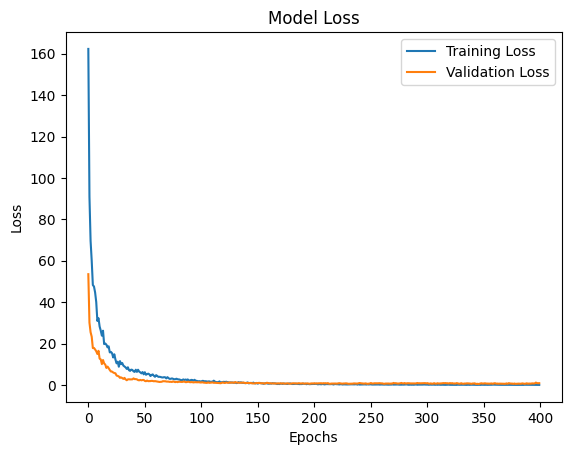

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend(['Training Loss','Validation Loss'], loc="upper right")

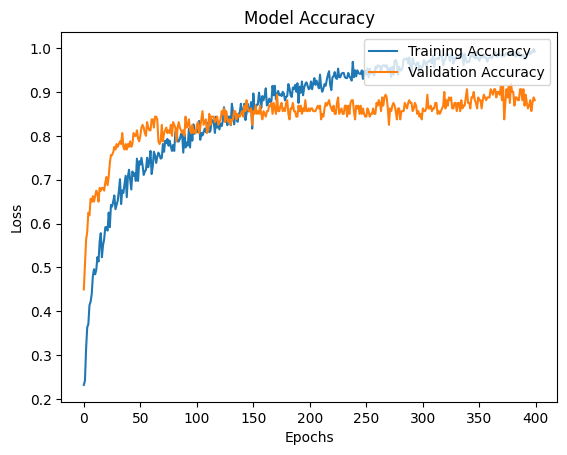

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend(['Training Accuracy','Validation Accuracy'], loc="upper right")

#### 3.2.4 Load the best CNN model


In [ ]:
model = load_model('./best_model_CNN.keras')

#### 3.2.5 CNN model performance assessment

In [ ]:
def evaluate_model_performance(y_true, y_pred, title='Confusion Matrix and Metrics'):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize confusion matrix row-wise
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Prepare annotation with counts and percentages
    annot = np.array([f'{count}\n({percentage:.1%})'
                      for count, percentage in zip(cm.flatten(), cm_normalized.flatten())])
    annot = annot.reshape(cm.shape)

    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=True,
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # Compute evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Print metrics and detailed classification report
    print("Accuracy:", round(accuracy, 3))
    print("Kappa:", round(kappa, 3))
    print("F1 Score:", round(f1, 3))
    print("\nDetailed Classification Report:\n")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step


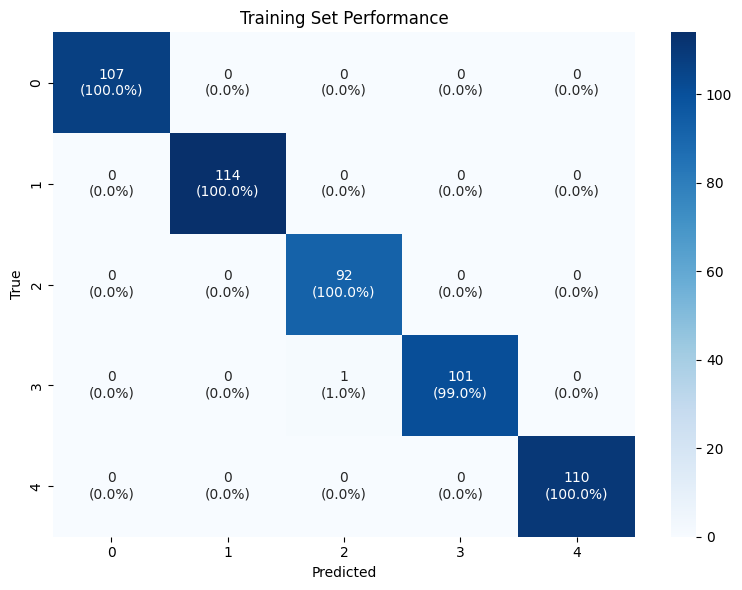

Accuracy: 0.998
Kappa: 0.998
F1 Score: 0.998

Detailed Classification Report:

              precision    recall  f1-score   support

           0      1.000     1.000     1.000       107
           1      1.000     1.000     1.000       114
           2      0.989     1.000     0.995        92
           3      1.000     0.990     0.995       102
           4      1.000     1.000     1.000       110

    accuracy                          0.998       525
   macro avg      0.998     0.998     0.998       525
weighted avg      0.998     0.998     0.998       525



In [ ]:
# Model performance at the Training phase

# convert encoded labels to int:
y_train_actual = np.argmax(y_train_encoded, axis=1)

# Predictions on training data
predictions = model.predict(X_train)
y_train_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_train_actual, y_train_pred, title='Training Set Performance')

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step


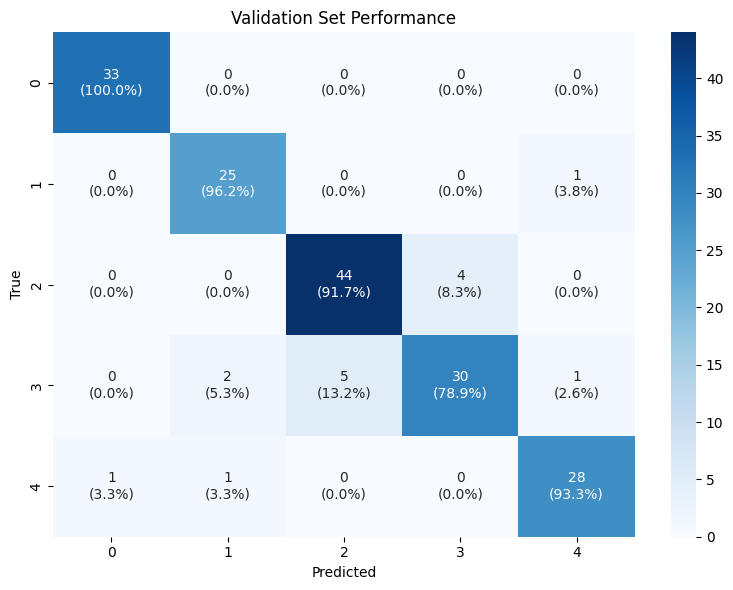

Accuracy: 0.914
Kappa: 0.892
F1 Score: 0.913

Detailed Classification Report:

              precision    recall  f1-score   support

           0      0.971     1.000     0.985        33
           1      0.893     0.962     0.926        26
           2      0.898     0.917     0.907        48
           3      0.882     0.789     0.833        38
           4      0.933     0.933     0.933        30

    accuracy                          0.914       175
   macro avg      0.915     0.920     0.917       175
weighted avg      0.914     0.914     0.913       175



In [ ]:
# Model performance at the Validation phase

# convert encoded labels to int:
y_val_actual = np.argmax(y_val_encoded, axis=1)

# Predictions on training data
predictions = model.predict(X_val)
y_val_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_val_actual, y_val_pred, title='Validation Set Performance')

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step


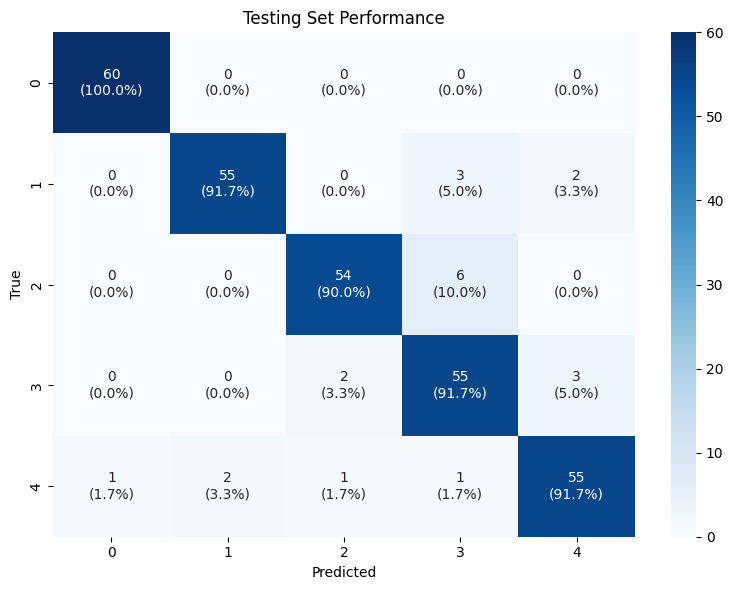

Accuracy: 0.93
Kappa: 0.912
F1 Score: 0.93

Detailed Classification Report:

              precision    recall  f1-score   support

           0      0.984     1.000     0.992        60
           1      0.965     0.917     0.940        60
           2      0.947     0.900     0.923        60
           3      0.846     0.917     0.880        60
           4      0.917     0.917     0.917        60

    accuracy                          0.930       300
   macro avg      0.932     0.930     0.930       300
weighted avg      0.932     0.930     0.930       300



In [ ]:
# Model performance at the Testing phase

# convert encoded labels to int:
y_test_actual = np.argmax(y_test_encoded, axis=1)


# Predictions on training data
predictions = model.predict(X_test)
y_test_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_test_actual, y_test_pred, title='Testing Set Performance')

## 4. Applying popular CNN architectures for remote sensing image classification tasks

### 4.1. Applying the popular VGG16 CNN architecture

In [ ]:
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(X_train, y_train_encoded, test_size=0.25, random_state=42)

# Build training dataset
batch_size = 16

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded)) \
                                 .shuffle(1024, reshuffle_each_iteration=True) \
                                 .batch(batch_size, drop_remainder=True) \
                                 .prefetch(tf.data.AUTOTUNE)

# Build validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded)) \
                                .batch(batch_size, drop_remainder=True) \
                                .prefetch(tf.data.AUTOTUNE)

model = customCNN(input_shape=inputShape, numClasses = num_classes)
model.compile(optimizer=Adam(learning_rate=1e-5),  loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# modified VGG16 for small image dimension

def VGG16(input_shape, numClasses):
    # Input layer
    inputs = Input(shape=input_shape, name='input')

    # Block 1: 2 x (64 conv) + max pooling
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
    # x = MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x) # modifying structure due to small image size
    x = MaxPooling2D((2, 2), name='block1_pool')(x)

    # Block 2: 2 x (128 conv) + max pooling
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
    # x = MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x) # modifying structure due to small image size
    x = MaxPooling2D((2, 2), name='block2_pool')(x)

    # Block 3: 3 x (256 conv) + max pooling
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
    # x = MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)
    x = MaxPooling2D((2, 2), name='block3_pool')(x)

    # # Block 4: 3 x (512 conv) + max pooling
    # x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1')(x)
    # x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2')(x)
    # x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3')(x)
    # # x = MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool')(x)
    # x = MaxPooling2D((2, 2), name='block4_pool')(x)

    # # Block 5: 3 x (512 conv) + max pooling
    # x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1')(x)
    # x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2')(x)
    # x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3')(x)
    # # x = MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool')(x)
    # x = MaxPooling2D((2, 2), name='block5_pool')(x)

    # Instead of further pooling (on Block 4, and 5), use global pooling to keep spatial info
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)  # 8x8 -> 256 features

    # Fully connected layers
    x = Flatten(name='flatten')(x)
    x = Dense(4096, activation='relu', name='fc1')(x)
    x = Dropout(0.5, name='dropout1')(x)
    x = Dense(4096, activation='relu', name='fc2')(x)
    x = Dropout(0.5, name='dropout2')(x)

    # Output layer with softmax activation for classification
    outputs = Dense(numClasses, activation='softmax', name='predictions')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='VGG16')
    return model

# Example usage:
modelVGG = VGG16(input_shape=inputShape, numClasses = num_classes)

modelVGG.compile(optimizer=Adam(learning_rate=1e-5),  loss='categorical_crossentropy', metrics=['accuracy'])
modelVGG.summary()

Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,595,717 (74.75 MB)

 Trainable params: 19,595,717 (74.75 MB)

 Non-trainable params: 0 (0.00 B)

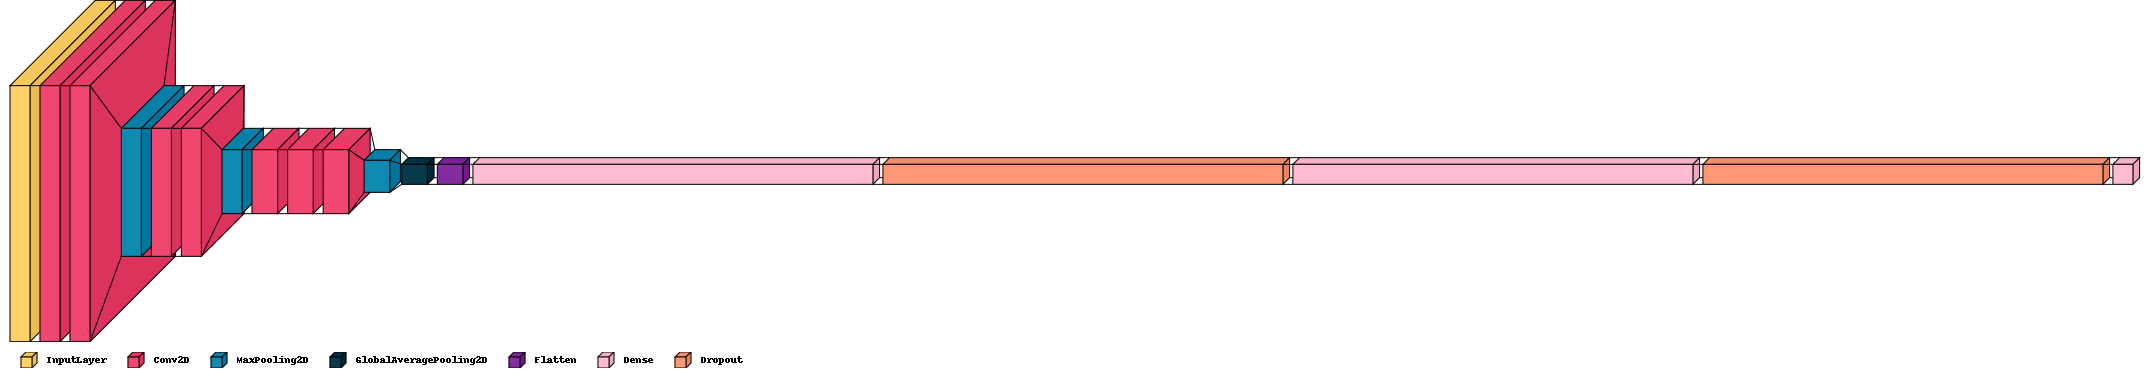

In [ ]:
visualkeras.layered_view(modelVGG, legend=True)

#### Train Model

In [ ]:
checkpoint_path = './best_model_VGG16.keras'

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

In [ ]:
history = modelVGG.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=100,
    callbacks=[checkpoint, VerboseEvery10()],
    verbose=0
)

Epoch 10: Loss=1.0985, Validation Loss=0.6034, Accuracy=0.7214, Validation Accuracy=0.8359
Epoch 20: Loss=0.5087, Validation Loss=0.3267, Accuracy=0.8255, Validation Accuracy=0.8984
Epoch 30: Loss=0.3782, Validation Loss=0.2292, Accuracy=0.8828, Validation Accuracy=0.9219
Epoch 40: Loss=0.1680, Validation Loss=0.2519, Accuracy=0.9401, Validation Accuracy=0.9297
Epoch 50: Loss=0.2332, Validation Loss=0.1640, Accuracy=0.9167, Validation Accuracy=0.9688
Epoch 60: Loss=0.1095, Validation Loss=0.2644, Accuracy=0.9583, Validation Accuracy=0.9219
Epoch 70: Loss=0.1147, Validation Loss=0.2050, Accuracy=0.9609, Validation Accuracy=0.9453
Epoch 80: Loss=0.0727, Validation Loss=0.1713, Accuracy=0.9714, Validation Accuracy=0.9688
Epoch 90: Loss=0.0598, Validation Loss=0.1230, Accuracy=0.9766, Validation Accuracy=0.9766
Epoch 100: Loss=0.0420, Validation Loss=0.1242, Accuracy=0.9896, Validation Accuracy=0.9531


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


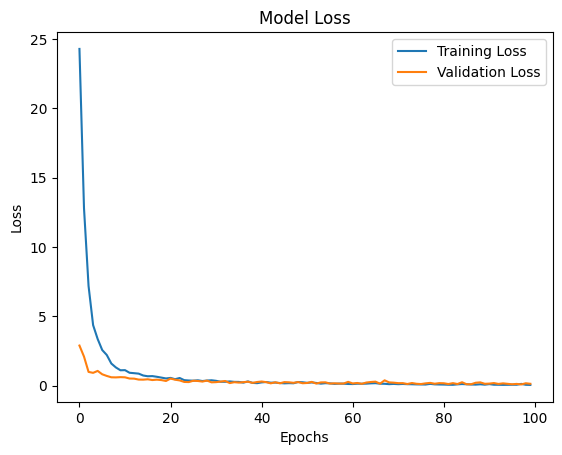

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend(['Training Loss','Validation Loss'], loc="upper right")

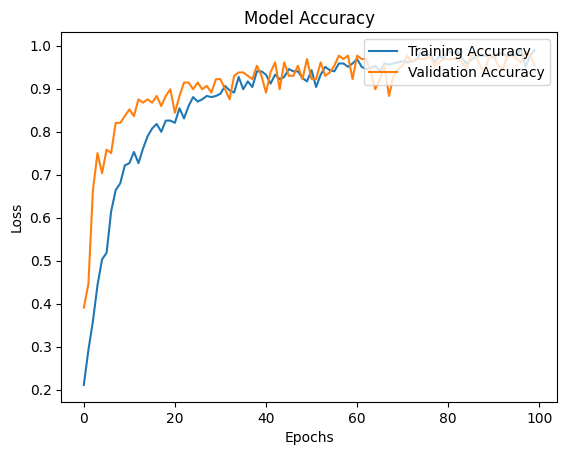

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend(['Training Accuracy','Validation Accuracy'], loc="upper right")

In [ ]:
# best model
bestVGG = load_model('./best_model_VGG16.keras')

#### VGG16 Evaluation

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step


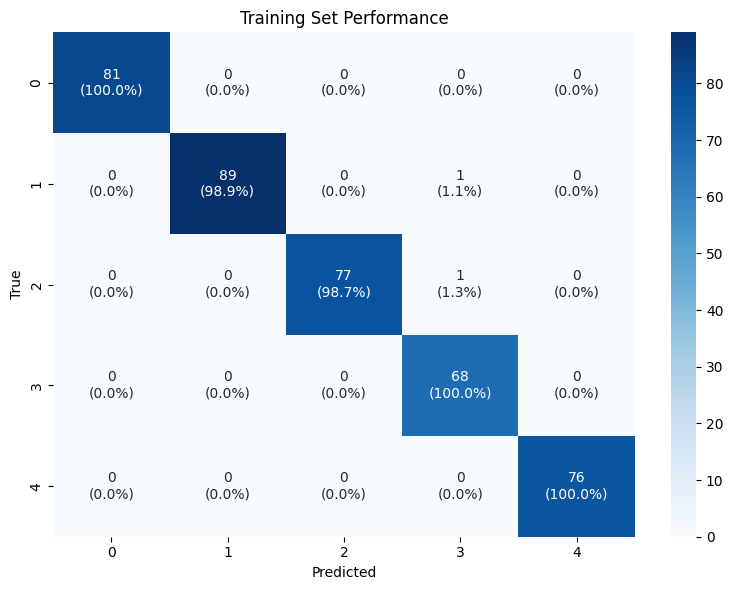

Accuracy: 0.995
Kappa: 0.994
F1 Score: 0.995

Detailed Classification Report:

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        81
           1      1.000     0.989     0.994        90
           2      1.000     0.987     0.994        78
           3      0.971     1.000     0.986        68
           4      1.000     1.000     1.000        76

    accuracy                          0.995       393
   macro avg      0.994     0.995     0.995       393
weighted avg      0.995     0.995     0.995       393



In [ ]:
# Model performance at the Training phase

# convert encoded labels to int:
y_train_actual = np.argmax(y_train_encoded, axis=1)

# Predictions on training data
predictions = bestVGG.predict(X_train)
y_train_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_train_actual, y_train_pred, title='Training Set Performance')

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step


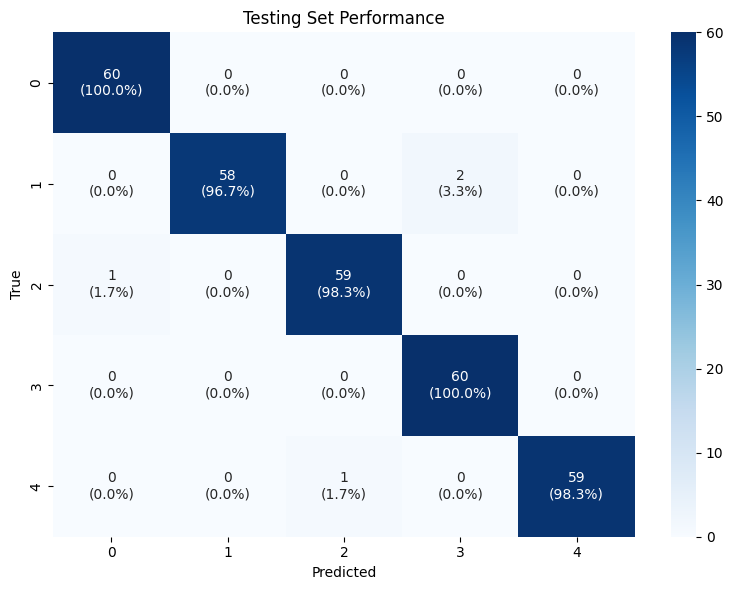

Accuracy: 0.987
Kappa: 0.983
F1 Score: 0.987

Detailed Classification Report:

              precision    recall  f1-score   support

           0      0.984     1.000     0.992        60
           1      1.000     0.967     0.983        60
           2      0.983     0.983     0.983        60
           3      0.968     1.000     0.984        60
           4      1.000     0.983     0.992        60

    accuracy                          0.987       300
   macro avg      0.987     0.987     0.987       300
weighted avg      0.987     0.987     0.987       300



In [ ]:
# Model performance at the Testing phase

# convert encoded labels to int:
y_test_actual = np.argmax(y_test_encoded, axis=1)

# Predictions on testing data
predictions = bestVGG.predict(X_test)
y_test_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_test_actual, y_test_pred, title='Testing Set Performance')

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 656ms/step


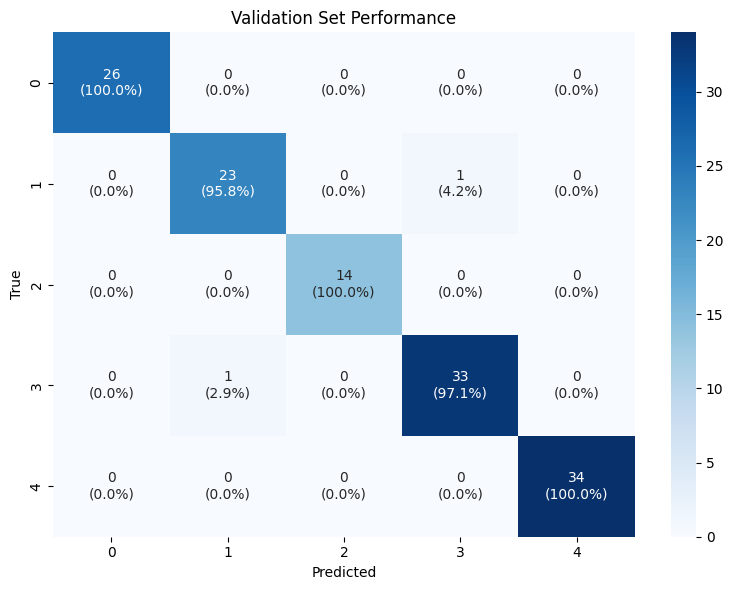

Accuracy: 0.985
Kappa: 0.981
F1 Score: 0.985

Detailed Classification Report:

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        26
           1      0.958     0.958     0.958        24
           2      1.000     1.000     1.000        14
           3      0.971     0.971     0.971        34
           4      1.000     1.000     1.000        34

    accuracy                          0.985       132
   macro avg      0.986     0.986     0.986       132
weighted avg      0.985     0.985     0.985       132



In [ ]:
# Model performance at the Validate phase

# convert encoded labels to int:
y_val_actual = np.argmax(y_val_encoded, axis=1)

# Predictions on Validation data
predictions = bestVGG.predict(X_val)
y_val_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_val_actual, y_val_pred, title='Validation Set Performance')

### 4.2 Trying ResNET32

In [ ]:
def IdentityBlock(x, filters, kernel_size = 3, strides = 1):
    x_skip = x

    # Layer 1
    x = Conv2D(filters = filters, kernel_size = kernel_size, strides = strides, activation = None, padding = 'same')(x)
    x = BatchNormalization(axis = 3)(x)
    x = Activation(activation = 'relu')(x)

    # Layer 2
    x = Conv2D(filters = filters, kernel_size = kernel_size, strides = 1, activation = None, padding = 'same')(x)
    x = BatchNormalization(axis = 3)(x)

    if strides != 1 or x_skip.shape[-1] != filters:
        x_skip = Conv2D(filters, kernel_size = 1, strides=strides, padding = 'same')(x_skip)
        x_skip = BatchNormalization(axis = 3)(x_skip)

    x = Add()([x_skip, x])
    x = Activation(activation = 'relu')(x)

    return x

def ResNet34(input_shape, numClasses):
    inputs = Input(input_shape)

    # Initial convolution and pooling
    x = Conv2D(filters = 64, kernel_size = (7, 7), strides = 2, activation = None, padding = 'same')(inputs)
    x = BatchNormalization(axis = 3)(x)
    x = Activation(activation = 'relu')(x)
    x = MaxPooling2D(pool_size = (3, 3), strides = 2, padding = 'same')(x)

    # Conv2_x
    for _ in range(3):
        x = IdentityBlock(x, 64)

    # Conv3_x
    x = IdentityBlock(x, 128, strides=2)
    for _ in range(3):
        x = IdentityBlock(x, 128)

    # Conv4_x
    x = IdentityBlock(x, 256, strides=2)
    for _ in range(5):
        x = IdentityBlock(x, 256)

    # Conv5_x
    x = IdentityBlock(x, 512, strides=2)
    for _ in range(2):
        x = IdentityBlock(x, 512)

    # Global Pooling and Output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    outputs = Dense(numClasses, activation='softmax')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='ResNet34')
    return model

modelResNet34 = ResNet34(input_shape=inputShape, numClasses = num_classes)

modelResNet34.compile(optimizer=Adam(learning_rate=1e-5),  loss='categorical_crossentropy', metrics=['accuracy'])
modelResNet34.summary()

Model: "ResNet34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 13)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │     40,832 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_4[0][0]  

 Total params: 21,344,133 (81.42 MB)

 Trainable params: 21,327,109 (81.36 MB)

 Non-trainable params: 17,024 (66.50 KB)

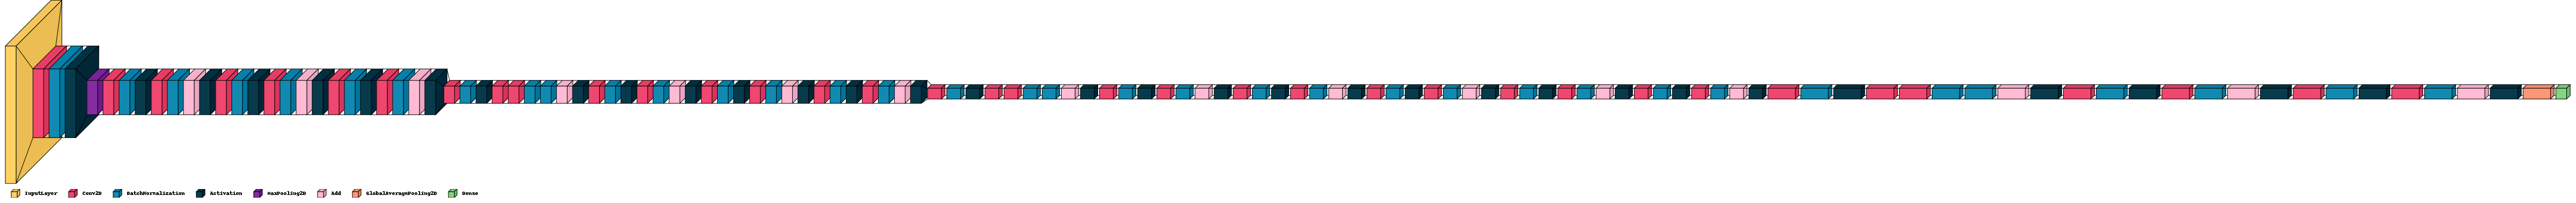

In [ ]:
visualkeras.layered_view(modelResNet34, legend = True)

In [ ]:
checkpoint_path = './best_model_ResNet34.keras'

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

history = modelResNet34.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=100,
    callbacks=[checkpoint, VerboseEvery10()],
    verbose=0
)

Epoch 10: Loss=0.1857, Validation Loss=0.8877, Accuracy=0.9531, Validation Accuracy=0.6641
Epoch 20: Loss=0.0645, Validation Loss=0.5653, Accuracy=0.9818, Validation Accuracy=0.7969
Epoch 30: Loss=0.0314, Validation Loss=0.6243, Accuracy=0.9922, Validation Accuracy=0.7891
Epoch 40: Loss=0.0125, Validation Loss=0.5575, Accuracy=1.0000, Validation Accuracy=0.8047
Epoch 50: Loss=0.0078, Validation Loss=0.6928, Accuracy=1.0000, Validation Accuracy=0.8047
Epoch 60: Loss=0.0133, Validation Loss=0.6070, Accuracy=0.9948, Validation Accuracy=0.8047
Epoch 70: Loss=0.0080, Validation Loss=0.7440, Accuracy=1.0000, Validation Accuracy=0.8203
Epoch 80: Loss=0.0313, Validation Loss=0.7739, Accuracy=0.9896, Validation Accuracy=0.7812
Epoch 90: Loss=0.0170, Validation Loss=0.9289, Accuracy=0.9922, Validation Accuracy=0.7734
Epoch 100: Loss=0.0028, Validation Loss=0.7106, Accuracy=1.0000, Validation Accuracy=0.8594


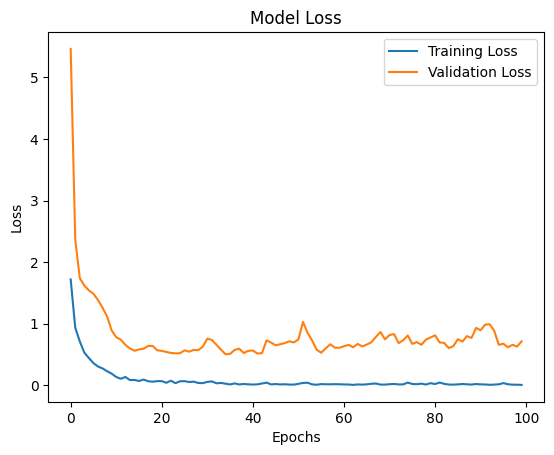

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend(['Training Loss','Validation Loss'], loc="upper right")

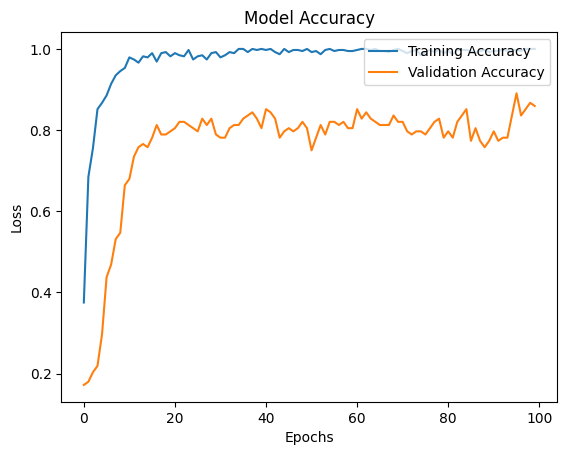

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend(['Training Accuracy','Validation Accuracy'], loc="upper right")

#### Resnet Evaluation

In [ ]:
# best model
bestResNet34 = load_model('./best_model_ResNet34.keras')

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step


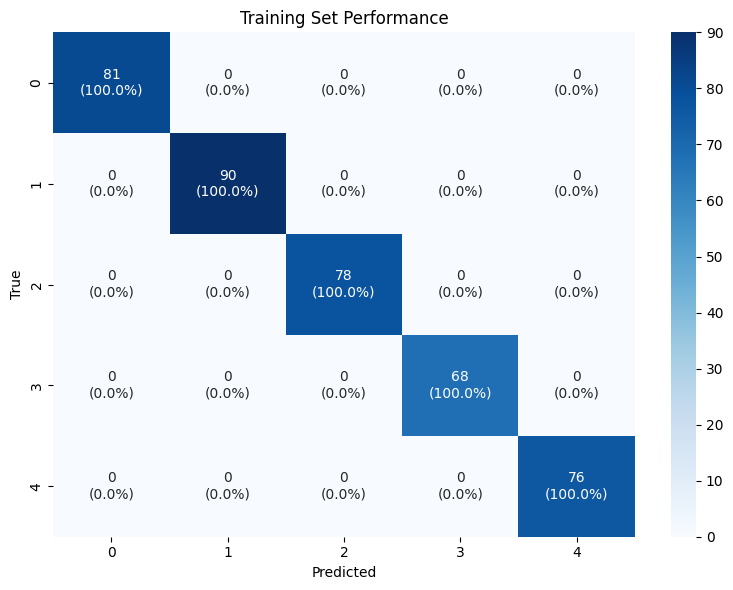

Accuracy: 1.0
Kappa: 1.0
F1 Score: 1.0

Detailed Classification Report:

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        81
           1      1.000     1.000     1.000        90
           2      1.000     1.000     1.000        78
           3      1.000     1.000     1.000        68
           4      1.000     1.000     1.000        76

    accuracy                          1.000       393
   macro avg      1.000     1.000     1.000       393
weighted avg      1.000     1.000     1.000       393



In [ ]:
# Model performance at the Training phase

# convert encoded labels to int:
y_train_actual = np.argmax(y_train_encoded, axis=1)

# Predictions on training data
predictions = bestResNet34.predict(X_train)
y_train_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_train_actual, y_train_pred, title='Training Set Performance')

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step


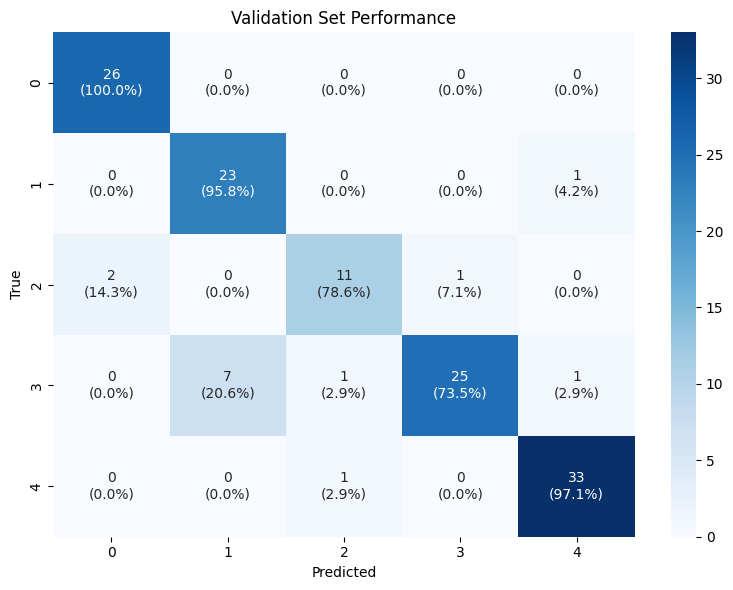

Accuracy: 0.894
Kappa: 0.865
F1 Score: 0.892

Detailed Classification Report:

              precision    recall  f1-score   support

           0      0.929     1.000     0.963        26
           1      0.767     0.958     0.852        24
           2      0.846     0.786     0.815        14
           3      0.962     0.735     0.833        34
           4      0.943     0.971     0.957        34

    accuracy                          0.894       132
   macro avg      0.889     0.890     0.884       132
weighted avg      0.903     0.894     0.892       132



In [ ]:
# Model performance at the Validation phase

# convert encoded labels to int:
y_val_actual = np.argmax(y_val_encoded, axis=1)

# Predictions on validation data
predictions = bestResNet34.predict(X_val)
y_val_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_val_actual, y_val_pred, title='Validation Set Performance')

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step


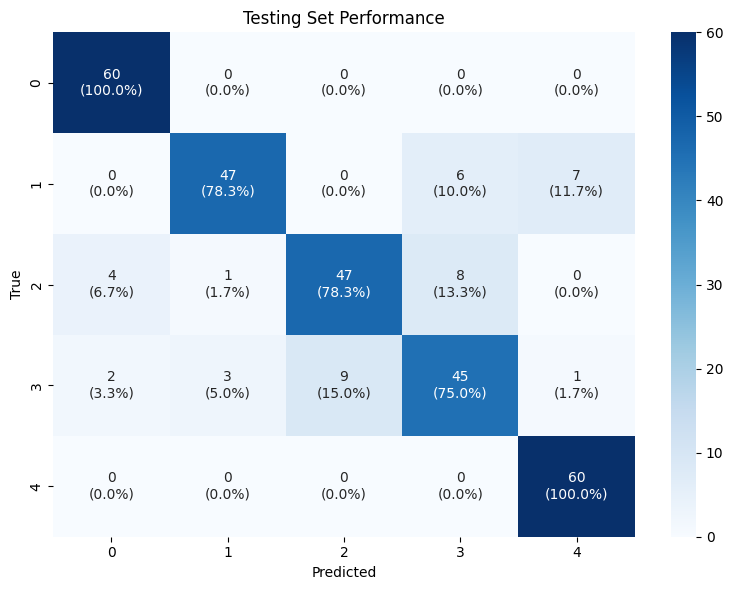

Accuracy: 0.863
Kappa: 0.829
F1 Score: 0.861

Detailed Classification Report:

              precision    recall  f1-score   support

           0      0.909     1.000     0.952        60
           1      0.922     0.783     0.847        60
           2      0.839     0.783     0.810        60
           3      0.763     0.750     0.756        60
           4      0.882     1.000     0.938        60

    accuracy                          0.863       300
   macro avg      0.863     0.863     0.861       300
weighted avg      0.863     0.863     0.861       300



In [ ]:
# Model performance at the Testing phase

# convert encoded labels to int:
y_est_actual = np.argmax(y_test_encoded, axis=1)

# Predictions on testing data
predictions = bestResNet34.predict(X_test)
y_test_pred = np.argmax(predictions, axis=1)

evaluate_model_performance(y_test_actual, y_test_pred, title='Testing Set Performance')